In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Cardiovascular_Disease_range_1000_.csv to Cardiovascular_Disease_range_1000_.csv


In [4]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("Initial shape:", df.shape)
print(df.head())

Initial shape: (1000, 13)
   age  gender  chestpain  restingBP  serumcholestrol  fastingbloodsugar  \
0   53       1          2        171                0                  0   
1   40       1          0         94              229                  0   
2   49       1          2        133              142                  0   
3   43       1          0        138              295                  1   
4   31       1          1        199                0                  0   

   restingrelectro  maxheartrate  exerciseangia  oldpeak  slope  \
0                1           147              0      5.3      3   
1                1           115              0      3.7      1   
2                0           202              1      5.0      1   
3                1           153              0      3.2      2   
4                2           136              0      5.3      3   

   noofmajorvessels  target  
0                 3       1  
1                 1       0  
2                 0     

In [5]:
dup_count = df.duplicated().sum()
print("Duplicate rows found:", dup_count)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 0
Shape after removing duplicates: (1000, 13)


In [6]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64


In [7]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64


In [8]:
leak_cols = [c for c in df.columns if c.lower() in ['id', 'patientid']]
if leak_cols:
    df = df.drop(columns=leak_cols)
    print("Dropped leakage/ID columns:", leak_cols)

In [9]:
print("\nData types:\n", df.dtypes)
for col in df.columns:
    print(col, "-> unique values:", df[col].nunique())


Data types:
 age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object
age -> unique values: 61
gender -> unique values: 2
chestpain -> unique values: 4
restingBP -> unique values: 95
serumcholestrol -> unique values: 344
fastingbloodsugar -> unique values: 2
restingrelectro -> unique values: 3
maxheartrate -> unique values: 129
exerciseangia -> unique values: 2
oldpeak -> unique values: 63
slope -> unique values: 4
noofmajorvessels -> unique values: 4
target -> unique values: 2


In [10]:
print("\nTarget distribution:\n", df['target'].value_counts())

print("\nFinal shape after Step 1:", df.shape)


Target distribution:
 target
1    580
0    420
Name: count, dtype: int64

Final shape after Step 1: (1000, 13)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
num_cols = ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']

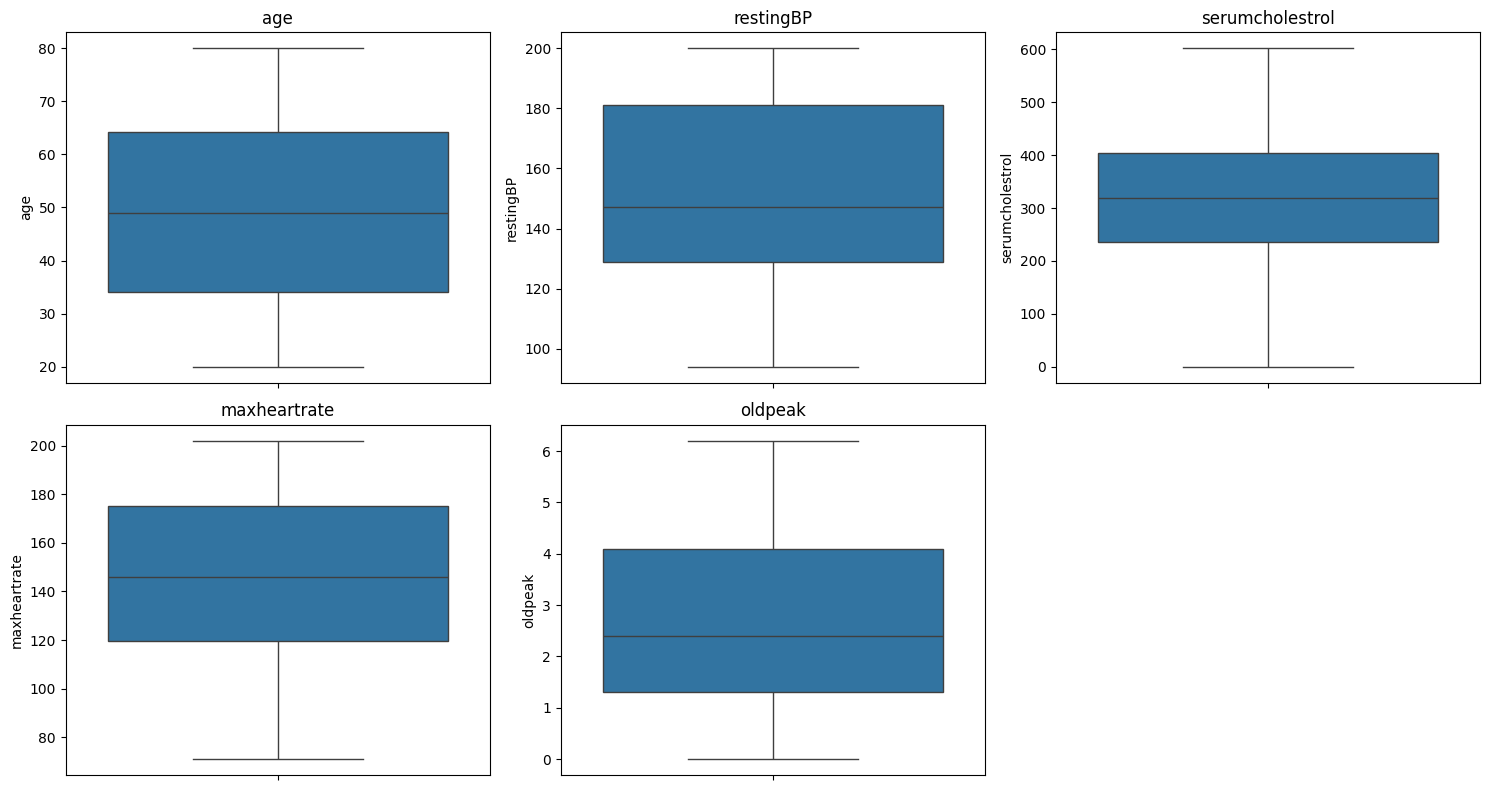

In [13]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [16]:
def count_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

print("Outlier summary (IQR method):\n")
for col in num_cols:
    n_out, low, up = count_outliers_iqr(df, col)
    print(f"{col}: {n_out} outliers | valid range = [{low:.2f}, {up:.2f}]")

Outlier summary (IQR method):

age: 0 outliers | valid range = [-11.38, 109.62]
restingBP: 0 outliers | valid range = [51.00, 259.00]
serumcholestrol: 0 outliers | valid range = [-17.00, 657.00]
maxheartrate: 0 outliers | valid range = [36.88, 257.88]
oldpeak: 0 outliers | valid range = [-2.90, 8.30]


In [18]:
for col in num_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

age: 0 zero values
restingBP: 0 zero values
serumcholestrol: 53 zero values
maxheartrate: 0 zero values
oldpeak: 19 zero values


In [19]:
# Step 2b: Treat serumcholestrol = 0 as missing, then impute
print("Before fix - serumcholestrol zero count:", (df['serumcholestrol'] == 0).sum())

# Replace 0 with NaN, then impute with median
df['serumcholestrol'] = df['serumcholestrol'].replace(0, np.nan)
df['serumcholestrol'].fillna(df['serumcholestrol'].median(), inplace=True)

print("After fix - serumcholestrol zero count:", (df['serumcholestrol'] == 0).sum())
print("\nUpdated serumcholestrol stats:")
print(df['serumcholestrol'].describe())

Before fix - serumcholestrol zero count: 53
After fix - serumcholestrol zero count: 0

Updated serumcholestrol stats:
count    1000.000000
mean      328.725000
std       110.034826
min        85.000000
25%       249.000000
50%       326.000000
75%       404.250000
max       602.000000
Name: serumcholestrol, dtype: float64


/tmp/ipykernel_2945/2232952878.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['serumcholestrol'].fillna(df['serumcholestrol'].median(), inplace=True)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
X = df.drop(columns=['target'])
y = df['target']

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (1000, 12)
Target distribution:
 target
1    580
0    420
Name: count, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (800, 12) Test shape: (200, 12)


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done. X_train_scaled sample:")
print(X_train_scaled[:3])


Scaling done. X_train_scaled sample:
[[ 0.15441387  0.55617351 -1.02156212 -0.12619826  1.96150783 -0.62747767
   0.32762107 -0.30111248  1.01257911 -1.04623474  0.45638604  0.79018313]
 [-0.18020761  0.55617351 -1.02156212 -0.96222512 -0.722939    1.59368222
  -0.97634339 -1.48820121 -0.98757716 -1.56859035 -1.52790109 -1.25559844]
 [ 1.66021056  0.55617351  2.13790836  1.61273762 -0.57584602  1.59368222
   1.63158554  0.61888129 -0.98757716 -0.93015572  1.4485296   0.79018313]]


In [24]:
!pip install xgboost catboost -q

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [25]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [26]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [27]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
print("XGBoost trained.")

XGBoost trained.


In [28]:
cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
print("CatBoost trained.")

print("\nAll 4 models trained successfully!")

CatBoost trained.

All 4 models trained successfully!


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
    "CatBoost": (cat_model, X_test)
}

results = []

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])
    print(f"{name}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")


Logistic Regression: Accuracy=0.9800, Precision=0.9746, Recall=0.9914, F1=0.9829
Random Forest: Accuracy=0.9850, Precision=0.9829, Recall=0.9914, F1=0.9871
XGBoost: Accuracy=0.9800, Precision=0.9828, Recall=0.9828, F1=0.9828
CatBoost: Accuracy=0.9900, Precision=0.9914, Recall=0.9914, F1=0.9914


In [30]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
results_df = results_df.round(4)

print("\n\nComparative Analysis Table:")
results_df



Comparative Analysis Table:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.980,0.9746,0.9914,0.9829
1,Random Forest,0.985,0.9829,0.9914,0.9871
2,XGBoost,0.980,0.9828,0.9828,0.9828
3,CatBoost,0.990,0.9914,0.9914,0.9914


In [31]:
# Check for overfitting: compare train vs test accuracy
for name, (model, X_tr, X_te) in [
    ("Logistic Regression", (lr_model, X_train_scaled, X_test_scaled)),
    ("Random Forest", (rf_model, X_train, X_test)),
    ("XGBoost", (xgb_model, X_train, X_test)),
    ("CatBoost", (cat_model, X_train, X_test))
]:
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc = accuracy_score(y_test, model.predict(X_te))
    print(f"{name}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Gap={train_acc-test_acc:.4f}")

Logistic Regression: Train Acc=0.9700, Test Acc=0.9800, Gap=-0.0100
Random Forest: Train Acc=1.0000, Test Acc=0.9850, Gap=0.0150
XGBoost: Train Acc=1.0000, Test Acc=0.9800, Gap=0.0200
CatBoost: Train Acc=1.0000, Test Acc=0.9900, Gap=0.0100


In [32]:
# Check correlation of each feature with target
print(df.corr()['target'].sort_values(ascending=False))

target               1.000000
slope                0.797358
chestpain            0.554228
noofmajorvessels     0.489866
restingBP            0.482387
restingrelectro      0.426837
serumcholestrol      0.368809
fastingbloodsugar    0.303233
maxheartrate         0.228343
oldpeak              0.098053
gender               0.015769
age                  0.008356
exerciseangia       -0.039874
Name: target, dtype: float64
